# Seasonal Agriculture Performance Analysis

For this project I'm looking at how farming performance (yield, profit, resource use, disease risk) changes across India's three cropping seasons : Kharif, Rabi and Zaid. The dataset has 4,000 farm records across 8 states and 8 crops.

My goal isn't just to run a bunch of charts, I wanted to actually figure out why one season might be doing worse than another, and back that up with numbers instead of just guessing.

1. Setup & Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Consistent plot styling for the whole notebook
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


2. Getting to know the data

Before I do anything else I want to know what I'm actually working with  how many rows, what type each column is, and roughly what the numbers look like.

In [2]:
print("Shape (rows, columns):", df.shape)
df.info()

Shape (rows, columns): (4000, 28)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha

In [3]:
# just want to see min/max/mean etc for the numeric columns
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [4]:
# What are the categorical (text) columns and their unique values?
categorical_cols = ['State', 'District', 'Crop', 'Season', 'Irrigation_Method']
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values -> {df[col].unique()}")

State: 8 unique values -> ['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']
District: 10 unique values -> ['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']
Crop: 8 unique values -> ['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']
Season: 3 unique values -> ['Kharif' 'Rabi' 'Zaid']
Irrigation_Method: 4 unique values -> ['Drip' 'Flood' 'Rainfed' 'Sprinkler']


## 3. Cleaning the data

### 3.1 Missing values

In [5]:
missing = df.isnull().sum()
missing[missing > 0]

,0
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32


A few columns have missing values — Rainfall_mm, Soil_Moisture_pct, Yield_Tonnes_Ha. None of them are more than ~1.5% missing so I didn't want to just drop those rows, that felt wasteful.

I filled them with the median for that season instead of the overall median — rainfall in Zaid vs Kharif is just completely different, so using one number for both didn't make sense to me.

In [6]:
cols_with_missing = ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']

for col in cols_with_missing:
    # fills each missing value with the median for that SAME season, not the overall median
    df[col] = df[col].fillna(df.groupby('Season')[col].transform('median'))

df[cols_with_missing].isnull().sum()  # should all be 0 now

,0
Rainfall_mm,0
Soil_Moisture_pct,0
Yield_Tonnes_Ha,0


### 3.2 Checking for duplicates

In [7]:
print("duplicate rows:", df.duplicated().sum())
print("duplicate farm ids:", df['Farm_ID'].duplicated().sum())
# both 0, so nothing to drop here

duplicate rows: 0
duplicate farm ids: 0


### 3.3 Outlier check

Yield_Tonnes_Ha looked really weird to me at first — some rows have yield over 100 t/ha while most are under 5. My first thought was "this has to be a data entry error." Turns out it isn't — checked it below.

In [8]:
df.groupby('Crop')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)

,Yield_Tonnes_Ha
Crop,
Sugarcane,46.641836
Maize,2.709074
Rice,2.431638
Wheat,2.108225
Chilli,1.541481
Groundnut,1.322642
Cotton,1.229311
Pulses,0.920766


Sugarcane. That's it, that's the whole explanation — sugarcane yield is measured in tonnes/hectare too but the crop itself is just way heavier per hectare than something like wheat or pulses. So this isn't bad data, I just need to remember not to compare yield across different crops directly later on.

## 4. Seasonal comparison

This is basically the main question of the whole project — does performance actually change across seasons, and by how much.

In [9]:
season_summary = df.groupby('Season')[['Rainfall_mm', 'Yield_Tonnes_Ha', 'Profit_INR', 'Disease_Pest_Risk_pct']].mean()
season_summary

,Rainfall_mm,Yield_Tonnes_Ha,Profit_INR,Disease_Pest_Risk_pct
Season,,,,
Kharif,852.112676,5.629438,178914.647555,54.467903
Rabi,435.937062,5.038451,87689.470191,40.482114
Zaid,299.123232,4.638872,-24804.824916,38.216667


Just from this table:
- Kharif gets way more rain (makes sense, monsoon season) and has the best average profit
- Zaid has the least rain AND a negative average profit?? that's not a small difference
- Disease/pest risk is also highest in Kharif — probably connected to the rain/humidity

Let me actually plot these instead of just reading numbers off a table.

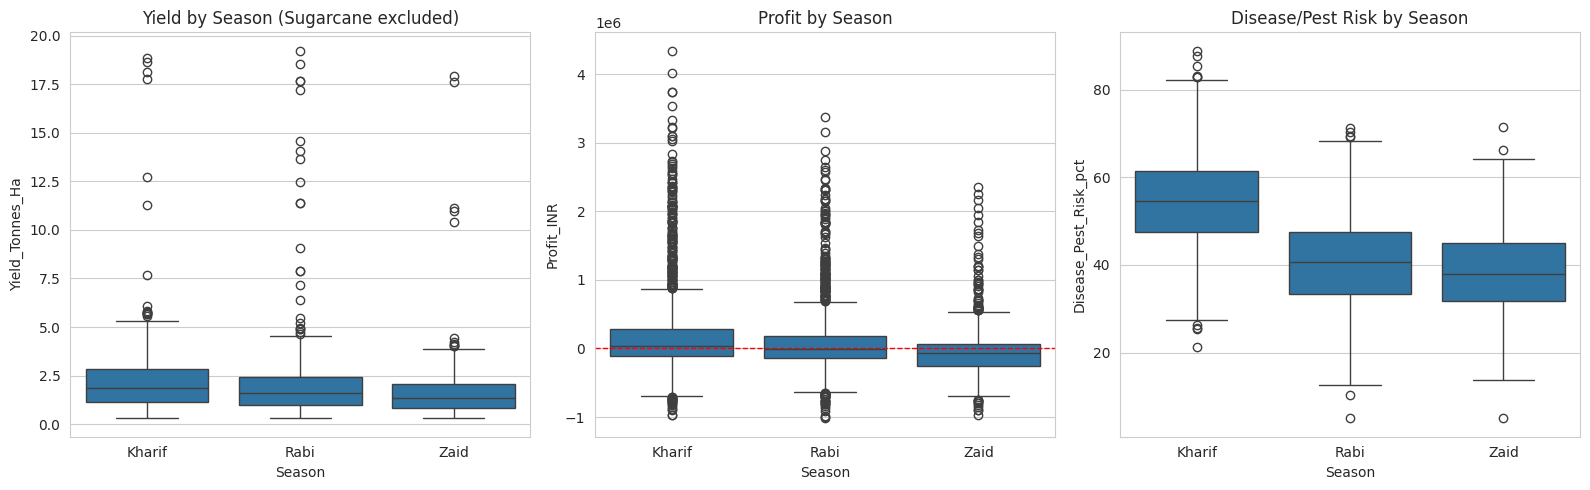

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# excluding sugarcane here just for this chart so it doesn't squash everything else to the bottom
sns.boxplot(x='Season', y='Yield_Tonnes_Ha', data=df[df['Yield_Tonnes_Ha'] < 20], ax=axes[0])
axes[0].set_title("Yield by Season (Sugarcane excluded)")

sns.boxplot(x='Season', y='Profit_INR', data=df, ax=axes[1])
axes[1].set_title("Profit by Season")
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)  # 0 line so I can see losses vs profit

sns.boxplot(x='Season', y='Disease_Pest_Risk_pct', data=df, ax=axes[2])
axes[2].set_title("Disease/Pest Risk by Season")

plt.tight_layout()
plt.savefig("chart_season_comparison.png")
plt.show()

Honestly this chart is a little hard to read because of how many outlier dots there are stretching the y-axis — the boxes all look kind of similar at a glance. So instead of trying to eyeball which box sits lower, I checked the actual loss percentage per season below.

In [11]:
# checking the actual % of farms with negative profit per season since the chart was hard to read
loss_rate = df.groupby('Season')['Profit_INR'].apply(lambda x: (x < 0).mean() * 100)
loss_rate.round(1)

,Profit_INR
Season,
Kharif,42.2
Rabi,51.1
Zaid,64.5


Yeah that confirms it — 64% of Zaid farms are running at a loss vs 42% in Kharif. Good reminder to myself: don't trust what a chart *looks* like if the number can just be checked directly.

## 5. Resource usage by season

If Zaid is doing badly, is it because farmers are putting in less effort/resources, or more?

In [12]:
resource_summary = df.groupby('Season')[['Water_Used_m3', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha']].mean()
resource_summary

,Water_Used_m3,Fertilizer_kg_ha,Pesticide_Litre_ha
Season,,,
Kharif,6102.201237,187.077965,5.079747
Rabi,5846.987093,185.407068,5.024690
Zaid,6419.893939,184.638047,5.171212


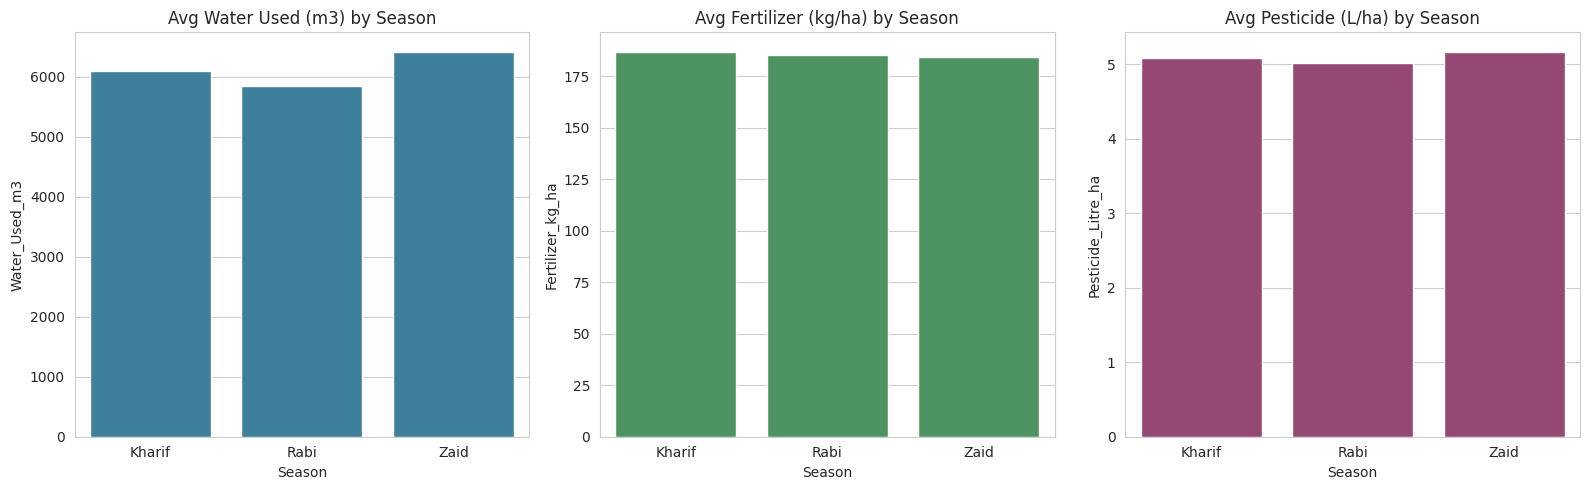

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.barplot(x=resource_summary.index, y=resource_summary['Water_Used_m3'], ax=axes[0], color="#2E86AB")
axes[0].set_title("Avg Water Used (m3) by Season")

sns.barplot(x=resource_summary.index, y=resource_summary['Fertilizer_kg_ha'], ax=axes[1], color="#42A05A")
axes[1].set_title("Avg Fertilizer (kg/ha) by Season")

sns.barplot(x=resource_summary.index, y=resource_summary['Pesticide_Litre_ha'], ax=axes[2], color="#A23B72")
axes[2].set_title("Avg Pesticide (L/ha) by Season")

plt.tight_layout()
plt.savefig("chart_resource_usage.png")
plt.show()

Water usage in Zaid is actually higher than Rabi, even though Zaid gets less rain — so farmers are compensating with more irrigation, but it's not paying off in yield or profit. That's kind of the opposite of what I expected going in.

## 6. What actually drives yield and profit?

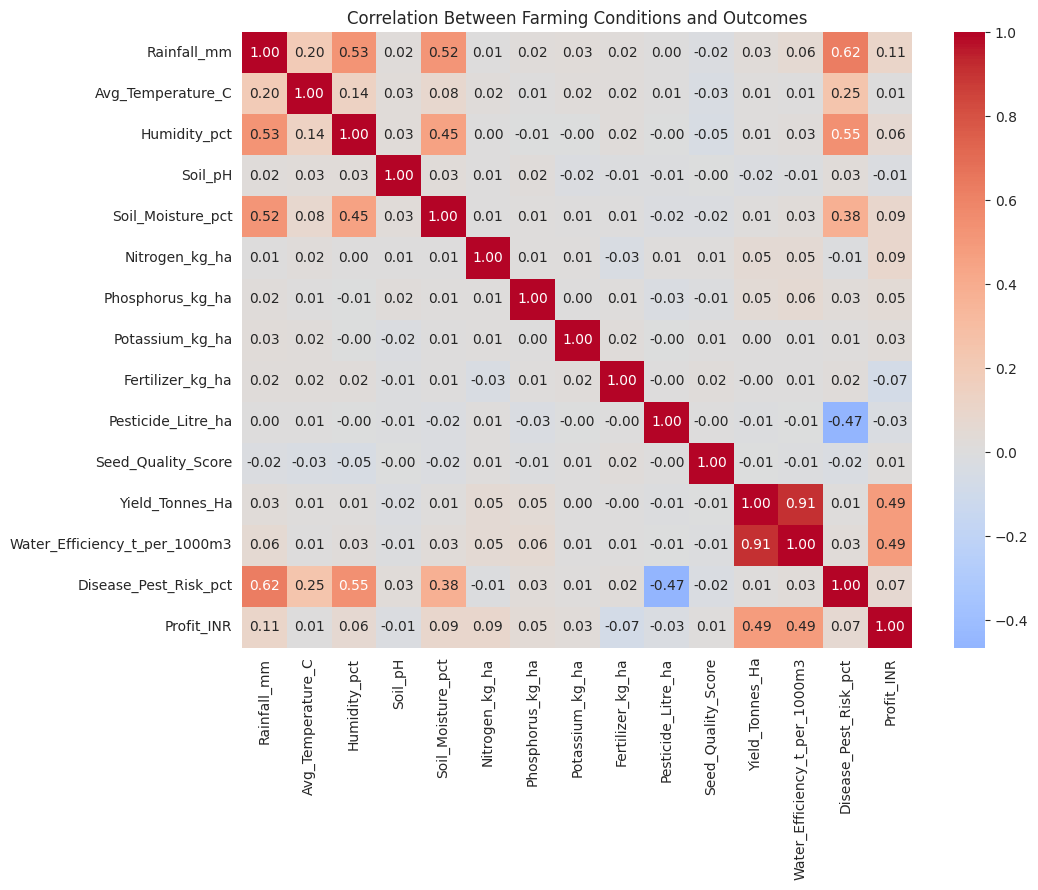

In [14]:
numeric_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Soil_pH', 'Soil_Moisture_pct',
                'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha',
                'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Water_Efficiency_t_per_1000m3',
                'Disease_Pest_Risk_pct', 'Profit_INR']

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Between Farming Conditions and Outcomes")
plt.tight_layout()
plt.savefig("chart_correlation_heatmap.png")
plt.show()

In [15]:
# What correlates most strongly with Yield specifically?
corr_matrix['Yield_Tonnes_Ha'].sort_values(ascending=False)

,Yield_Tonnes_Ha
Yield_Tonnes_Ha,1.000000
Water_Efficiency_t_per_1000m3,0.912561
Profit_INR,0.488459
Nitrogen_kg_ha,0.053167
Phosphorus_kg_ha,0.047974
Rainfall_mm,0.028836
Disease_Pest_Risk_pct,0.014351
Humidity_pct,0.012337
Soil_Moisture_pct,0.011101
Avg_Temperature_C,0.010026


I expected at least one of the soil/weather columns to jump out here but nothing really does the highest one (besides Water_Efficiency, which is basically calculated from yield anyway so it doesn't count) is Nitrogen at 0.05, which is basically nothing.

So my takeaway is: no single factor is "the" reason for yield differences. It's probably some mix of crop + season + irrigation together rather than any one input.

Disease risk is a lot clearer though it lines up strongly with Rainfall (0.62) and Humidity (0.55), and goes down with more Pesticide use (-0.47). That part makes intuitive sense.

## 7. Crop performance across seasons

In [16]:
crop_season_profit = df.groupby(['Crop', 'Season'])['Profit_INR'].mean().unstack()
crop_season_profit

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,9.543804e+05,638572.496933,448659.093750
Cotton,2.169995e+05,107343.587065,-53925.336957
Groundnut,1.082654e+05,10416.542373,-68872.500000
Maize,-3.933267e+04,-89133.403433,-194049.166667
Pulses,4.333890e+04,-14309.136150,-139227.806452
Rice,-6.490340e+04,-98427.868613,-227239.343137
Sugarcane,1.000791e+06,731612.860465,583635.803922
Wheat,-1.058719e+05,-119954.565401,-193208.952941


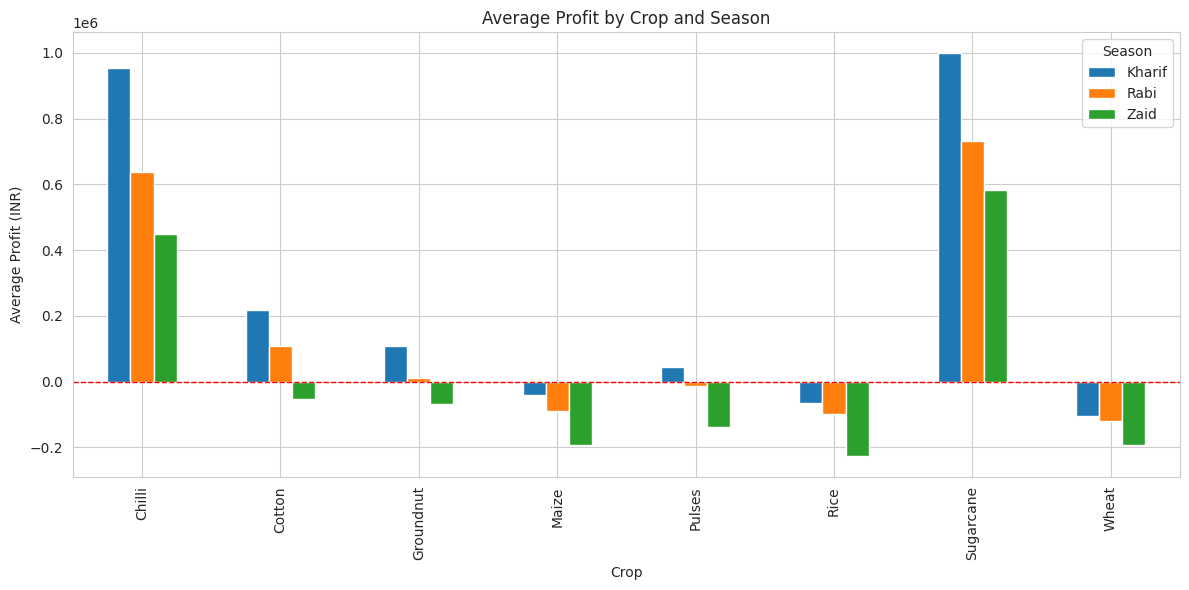

In [17]:
crop_season_profit.plot(kind='bar', figsize=(12, 6))
plt.title("Average Profit by Crop and Season")
plt.ylabel("Average Profit (INR)")
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.legend(title="Season")
plt.tight_layout()
plt.savefig("chart_crop_season_profit.png")
plt.show()

This is the chart that made the most sense to me out of everything so far — profit really depends on crop AND season together, not one or the other. Rice, Wheat, Maize and Pulses all dip into the negative in at least one season, but Sugarcane, Chilli, Cotton and Groundnut stay positive across all three (even if lower in Zaid). So a blanket 'grow X in season Y' rule wouldn't really work here.

## 8. Does irrigation method matter?

In [18]:
irrigation_profit = df.groupby('Irrigation_Method')['Profit_INR'].mean().sort_values(ascending=False)
irrigation_profit

,Profit_INR
Irrigation_Method,
Drip,219625.997814
Sprinkler,91121.079019
Rainfed,79050.365034
Flood,73354.022901


/tmp/ipykernel_6507/4118220511.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=irrigation_profit.index, y=irrigation_profit.values, palette="Blues_d")


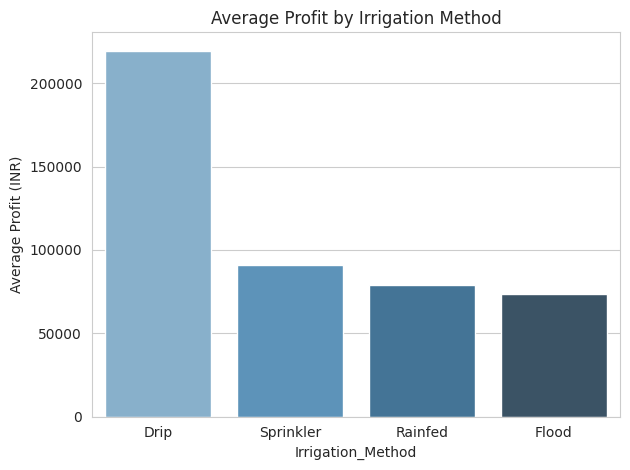

In [19]:
sns.barplot(x=irrigation_profit.index, y=irrigation_profit.values, palette="Blues_d")
plt.title("Average Profit by Irrigation Method")
plt.ylabel("Average Profit (INR)")
plt.tight_layout()
plt.savefig("chart_irrigation_profit.png")
plt.show()

Drip irrigation is clearly ahead of the other three methods here. Makes sense — it wastes less water than flood irrigation, so probably keeps yield up while cutting cost. This feels like the most actionable finding in the whole project honestly — farms on Flood/Rainfed could realistically switch.

## 9. What I found

- Zaid is the worst performing season overall includes least rain, more water usage relative to output, and the only season where most farms lose money (64% loss rate vs 42% in Kharif)
- Kharif has the highest disease/pest risk, which tracks with it also having the most rain and humidity
- Yield differences are mostly explained by crop type (sugarcane vs everything else), not by any single environmental factor
- Drip irrigation consistently does better on profit than the other three methods
- Profit depends on crop + season together including some crops swing from profit to loss depending on the season, so it's not just "this crop is good" or "this season is good"

**What I'd recommend based on this:**
- Farmers growing water-heavy crops in Zaid season are the ones who need the most support subsidized drip irrigation seems like the most direct fix given what the data shows
- Pest/disease management resources should probably be front-loaded into Kharif season rather than spread evenly across the year
- Irrigation method is worth a closer look at a larger scale the profit gap for Drip is big enough that it's not just noise
